# Real exercises: Data Capture

Use this notebook to record exercise data at the gym: pull ups, dips, 90° push ups, front level pulls, etc. Record myself with the phone on the sagital and frontal planes to understand everything better, make sure to produce reliable stationary periods between repetitions to evaluate velocity ZUPTs and that the signal processing pipeline on the device is disabled. 

## Setup

In [4]:
# Run in case of ModuleNotFoundError:
# cd ./signal-utils
# pip install -e .

from signal_utils import IMUSampleReceiver, IMUSampleWriter
import numpy as np
import matplotlib.pyplot as plt


def plotRawData(seq: np.ndarray, f: np.ndarray, w: np.ndarray) -> None:
    if seq.size == 0:
        print("No samples available to plot")
        return

    fig, axes = plt.subplots(4, 2, figsize=(12, 8))

    lowerBoundAccel = min(np.min(f[:, 0]), np.min(f[:, 1]), np.min(f[:, 2]))
    upperBoundAccel = max(np.max(f[:, 0]), np.max(f[:, 1]), np.max(f[:, 2]))

    lowerBoundGyro = min(np.min(w[:, 0]), np.min(w[:, 1]), np.min(w[:, 2]))
    upperBoundGyro = max(np.max(w[:, 0]), np.max(w[:, 1]), np.max(w[:, 2]))

    axes[0, 0].set_title("Axis-wise specific force")
    fLabels = ["fx (m/s^2)", "fy (m/s^2)", "fz (m/s^2)"]
    for i in range(3):
        axes[i, 0].plot(seq, f[:, i], color="blue")
        axes[i, 0].set_ylabel(fLabels[i])
        axes[i, 0].set_xlabel("seq")
        axes[i, 0].set_ylim(lowerBoundAccel, upperBoundAccel)
        axes[i, 0].grid()
    axes[3, 0].plot(seq, np.linalg.norm(f, axis=1), color="blue", linestyle="--")
    axes[3, 0].set_ylabel("Euclidean norm (m/s^2)")
    axes[3, 0].set_xlabel("seq")
    axes[3, 0].grid()

    axes[0, 1].set_title("Axis-wise angular velocity")
    wLabels = ["roll (deg/s)", "pitch (deg/s)", "yaw (deg/s)"]
    for i in range(3):
        axes[i, 1].plot(seq, w[:, i], color="red")
        axes[i, 1].set_ylabel(wLabels[i])
        axes[i, 1].set_xlabel("seq")
        axes[i, 1].set_ylim(lowerBoundGyro, upperBoundGyro)
        axes[i, 1].grid()
    axes[3, 1].plot(seq, np.linalg.norm(w, axis=1), color="red", linestyle="--")
    axes[3, 1].set_ylabel("Euclidean norm (deg/s)")
    axes[3, 1].set_xlabel("seq")
    axes[3, 1].grid()

    fig.suptitle("IMU data (sensor frame)")
    plt.tight_layout()
    plt.show()

## Recording

In [5]:
# Run in case of rare bluetooth errors:
# sudo systemctl restart bluetooth

RECORDING_DURATION_SECONDS = 15.0
EXPORTED_FILE_NAME = "test.csv"
# EXPORTED_FILE_NAME = "icm42688p-90-deg-push-ups-1.csv"
# EXPORTED_FILE_NAME = "icm42688p-90-deg-push-ups-2.csv"
# EXPORTED_FILE_NAME = "icm42688p-pull-ups-1.csv"
# EXPORTED_FILE_NAME = "icm42688p-pull-ups-2.csv"
# EXPORTED_FILE_NAME = "icm42688p-pull-ups-3.csv"
# EXPORTED_FILE_NAME = "icm42688p-dips-1.csv"
# EXPORTED_FILE_NAME = "icm42688p-dips-2.csv"
# EXPORTED_FILE_NAME = "icm42688p-dips-3.csv"
# EXPORTED_FILE_NAME = "icm42688p-fl-pulls.csv"

receiver = IMUSampleReceiver(RECORDING_DURATION_SECONDS)
writer = IMUSampleWriter()
try:
    await receiver.connect()
    seq, f, w = await receiver.receive()
finally:
    await receiver.disconnect()

if seq is not None and f is not None and w is not None:
    writer.write(EXPORTED_FILE_NAME, seq, f, w)

Scanning for BLE device 'Gym-IMU' for up to 90s...
Found device: name=Gym-IMU, address=94:A9:90:6D:1C:1E
Connected to 94:A9:90:6D:1C:1E (Gym-IMU)
Subscribed to IMU notifications
Press the wearable button now to start transmission. Waiting for first sample...
Receiving samples for 15 seconds...
Notification #17, sample from batch: f: (-0.136056, 0.397888, -0.523822), w: (-40.816071, -62.547737, -8.547260), seq: 111
Notification #34, sample from batch: f: (-0.040927, -0.020577, 0.002285), w: (0.005636, 0.047029, 0.040459), seq: 225
Notification #51, sample from batch: f: (-0.051703, -0.035877, 0.000698), w: (0.014224, -0.023523, 0.032077), seq: 338
Notification #68, sample from batch: f: (-0.047558, -0.030505, 0.006246), w: (-0.011092, -0.025903, 0.007309), seq: 451
Notification #85, sample from batch: f: (-0.059058, -0.029317, 0.005883), w: (-0.024246, -0.020914, -0.037762), seq: 565
Notification #102, sample from batch: f: (-0.044232, -0.032795, -0.002651), w: (0.007113, 0.005277, 0.01

## Time Series Plotting

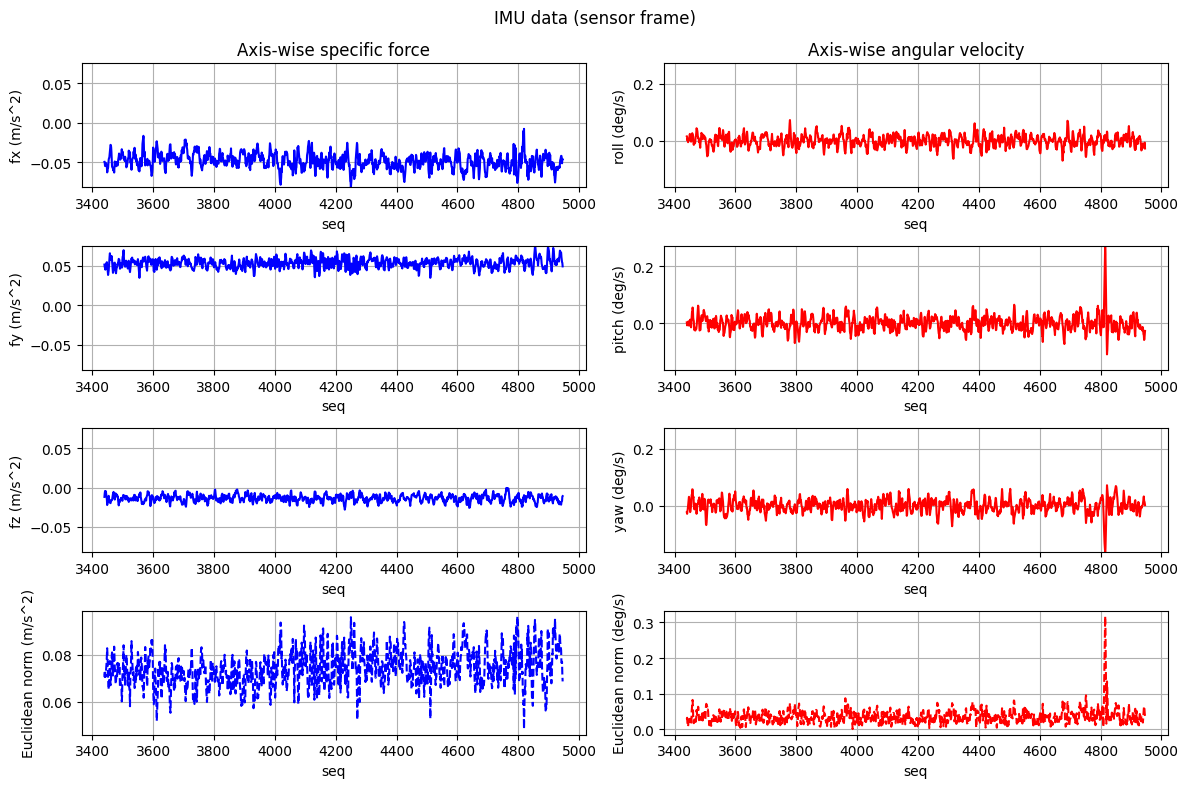

In [ ]:
if seq is not None and f is not None and w is not None:
    plotRawData(seq, f, w)